# 07_autoencoder_preprocessing
Goals:
- prepare CMAPSS data for anomaly detection
- define healthy and degraded operating regions
- generate healthy sequences for LSTM autoencoder training
- analyze degradation progression

In [12]:
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

print(PROCESSED_DIR)

df_train = pd.read_csv(PROCESSED_DIR / "train_fd001_processed.csv")

print(df_train.shape)
df_train.head()

/home/flaviu/licenta/data/processed
(20631, 27)


,unit,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s13,s14,s15,s16,s17,s18,s19,s20,s21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,0.183735,0.406802,0.309757,14.62,...,0.205882,0.199608,0.363986,0.03,0.333333,2388,100.0,0.713178,0.724662,125
1,1,2,0.0019,-0.0003,100.0,518.67,0.283133,0.453019,0.352633,14.62,...,0.279412,0.162813,0.411312,0.03,0.333333,2388,100.0,0.666667,0.731014,125
2,1,3,-0.0043,0.0003,100.0,518.67,0.343373,0.369523,0.370527,14.62,...,0.220588,0.171793,0.357445,0.03,0.166667,2388,100.0,0.627907,0.621375,125
3,1,4,0.0007,0.0000,100.0,518.67,0.343373,0.256159,0.331195,14.62,...,0.294118,0.174889,0.166603,0.03,0.333333,2388,100.0,0.573643,0.662386,125
4,1,5,-0.0019,-0.0002,100.0,518.67,0.349398,0.257467,0.404625,14.62,...,0.235294,0.174734,0.402078,0.03,0.416667,2388,100.0,0.589147,0.704502,125


In [14]:
HEALTHY_RUL_THRESHOLD = 100

healthy_df = df_train[df_train["RUL"] > HEALTHY_RUL_THRESHOLD]
degraded_df = df_train[df_train["RUL"] <= HEALTHY_RUL_THRESHOLD]

print("Healthy samples:", healthy_df.shape)
print("Degraded samples:", degraded_df.shape)

Healthy samples: (10531, 27)
Degraded samples: (10100, 27)


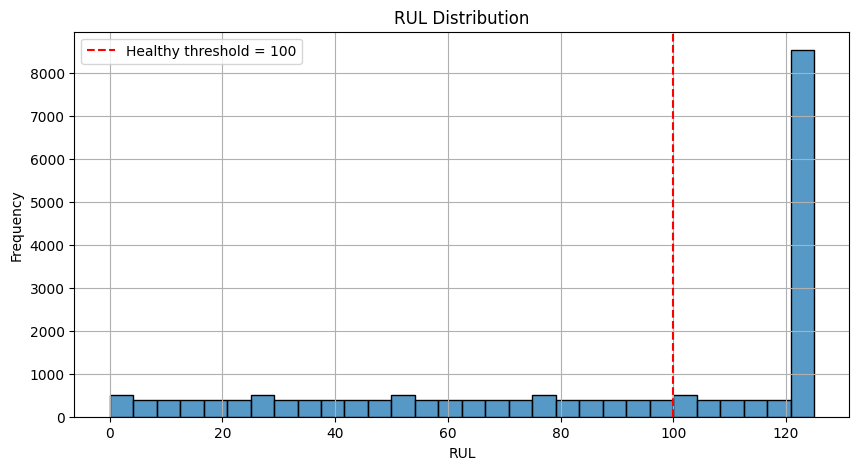

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(df_train["RUL"], bins=30)

plt.axvline(
    HEALTHY_RUL_THRESHOLD,
    color="red",
    linestyle="--",
    label=f"Healthy threshold = {HEALTHY_RUL_THRESHOLD}"
)

plt.title("RUL Distribution")
plt.xlabel("RUL")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)

plt.show()

In [16]:
feature_cols = pd.read_csv(
    PROCESSED_DIR / "fd001_feature_cols.csv",
    header=None
)[0].tolist()

feature_cols

['s2',
 's3',
 's4',
 's6',
 's7',
 's8',
 's9',
 's11',
 's12',
 's13',
 's14',
 's15',
 's17',
 's20',
 's21']

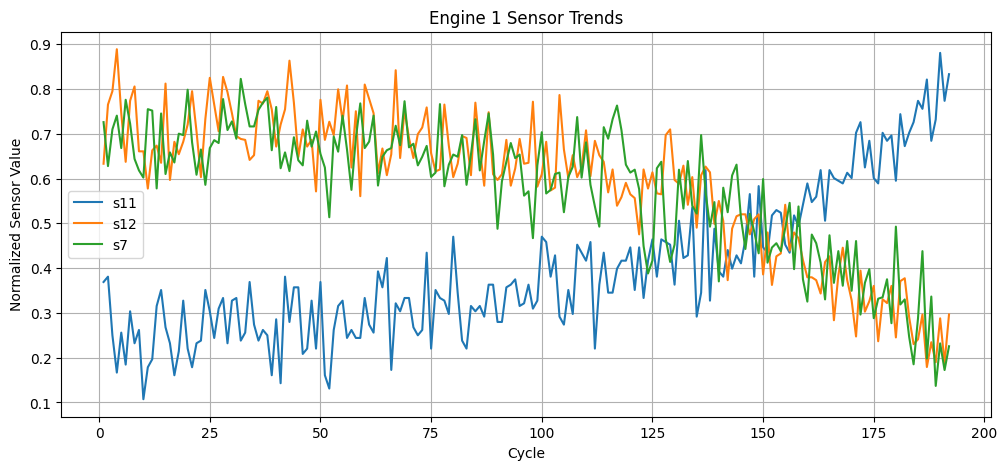

In [17]:
engine_id = 1

engine_df = df_train[df_train["unit"] == engine_id]

plt.figure(figsize=(12, 5))

plt.plot(engine_df["cycle"], engine_df["s11"], label="s11")
plt.plot(engine_df["cycle"], engine_df["s12"], label="s12")
plt.plot(engine_df["cycle"], engine_df["s7"], label="s7")

plt.xlabel("Cycle")
plt.ylabel("Normalized Sensor Value")
plt.title(f"Engine {engine_id} Sensor Trends")

plt.legend()
plt.grid(True)
plt.show()

In [18]:
SEQ_LENGTH = 30

HEALTHY_RUL_THRESHOLD = 120
ANOMALY_RUL_THRESHOLD = 30

print("Sequence length:", SEQ_LENGTH)
print("Healthy threshold:", HEALTHY_RUL_THRESHOLD)
print("Anomaly threshold:", ANOMALY_RUL_THRESHOLD)

Sequence length: 30
Healthy threshold: 120
Anomaly threshold: 30


In [19]:
def create_autoencoder_sequences_with_metadata(df, feature_cols, seq_length):
    X = []
    rul_list = []
    unit_list = []
    cycle_list = []

    for unit in df["unit"].unique():
        unit_df = df[df["unit"] == unit].sort_values("cycle").reset_index(drop=True)

        for i in range(len(unit_df) - seq_length + 1):
            seq = unit_df.iloc[i:i + seq_length][feature_cols].values

            final_row = unit_df.iloc[i + seq_length - 1]

            X.append(seq)
            rul_list.append(final_row["RUL"])
            unit_list.append(final_row["unit"])
            cycle_list.append(final_row["cycle"])

    return (
        np.array(X),
        np.array(rul_list),
        np.array(unit_list),
        np.array(cycle_list)
    )

In [20]:
X_all, rul_all, unit_all, cycle_all = create_autoencoder_sequences_with_metadata(
    df_train,
    feature_cols,
    SEQ_LENGTH
)

print("All sequences:", X_all.shape)
print("RUL values:", rul_all.shape)

All sequences: (17731, 30, 15)
RUL values: (17731,)


In [21]:


from sklearn.model_selection import train_test_split

healthy_mask = rul_all >= HEALTHY_RUL_THRESHOLD
anomaly_mask = rul_all <= ANOMALY_RUL_THRESHOLD

healthy_indices = np.where(healthy_mask)[0]
anomaly_indices = np.where(anomaly_mask)[0]

healthy_trainval_indices, healthy_test_indices = train_test_split(
    healthy_indices,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

X_healthy_trainval = X_all[healthy_trainval_indices]
X_healthy_test = X_all[healthy_test_indices]

eval_indices = np.concatenate([healthy_test_indices, anomaly_indices])

X_eval = X_all[eval_indices]
y_eval = np.where(rul_all[eval_indices] <= ANOMALY_RUL_THRESHOLD, 1, 0)

rul_eval = rul_all[eval_indices]
unit_eval = unit_all[eval_indices]
cycle_eval = cycle_all[eval_indices]

print("All healthy sequences:", len(healthy_indices))
print("Healthy train/val pool:", X_healthy_trainval.shape)
print("Healthy held-out test:", X_healthy_test.shape)
print("Anomaly sequences:", len(anomaly_indices))
print("Evaluation sequences:", X_eval.shape)
print("Evaluation healthy:", np.sum(y_eval == 0))
print("Evaluation anomalies:", np.sum(y_eval == 1))

All healthy sequences: 5794
Healthy train/val pool: (4635, 30, 15)
Healthy held-out test: (1159, 30, 15)
Anomaly sequences: 3100
Evaluation sequences: (4259, 30, 15)
Evaluation healthy: 1159
Evaluation anomalies: 3100


In [23]:


np.save(PROCESSED_DIR / "X_healthy_strict.npy", X_healthy_trainval)
np.save(PROCESSED_DIR / "X_healthy_test_strict.npy", X_healthy_test)

np.save(PROCESSED_DIR / "X_eval_strict.npy", X_eval)
np.save(PROCESSED_DIR / "y_eval_strict.npy", y_eval)

np.save(PROCESSED_DIR / "rul_all.npy", rul_all)
np.save(PROCESSED_DIR / "unit_all.npy", unit_all)
np.save(PROCESSED_DIR / "cycle_all.npy", cycle_all)

np.save(PROCESSED_DIR / "rul_eval_strict.npy", rul_eval)
np.save(PROCESSED_DIR / "unit_eval_strict.npy", unit_eval)
np.save(PROCESSED_DIR / "cycle_eval_strict.npy", cycle_eval)

print("Anomaly datasets saved.")

Anomaly datasets saved.
